Prédiction de tops géologiques par Deep Sets : depuis des puits annotés, apprendre la signature GR de chaque horizon, puis localiser cette signature dans les puits non annotés.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

In [74]:
df_logs = pd.read_parquet("logs.parquet")

print("\n--- APERÇU DES DONNÉES ---")
print(df_logs.head())

print("\n--- DIMENSIONS ---")
print(f"Lignes : {df_logs.shape[0]}")
print(f"Colonnes : {df_logs.shape[1]}")

print("\n--- COLONNES ---")
print(df_logs.columns.tolist())

print("\n--- TYPES DE DONNÉES ---")
print(df_logs.dtypes)

print("\n--- VALEURS MANQUANTES ---")
print(df_logs.isna().sum())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_logs.describe(include="all"))

df_tops = pd.read_parquet("tops.parquet")

print("\n--- APERÇU DES DONNÉES ---")
print(df_tops.head())

print("\n--- DIMENSIONS ---")
print(f"Lignes : {df_tops.shape[0]}")
print(f"Colonnes : {df_tops.shape[1]}")

print("\n--- COLONNES ---")
print(df_tops.columns.tolist())

print("\n--- TYPES DE DONNÉES ---")
print(df_tops.dtypes)

print("\n--- VALEURS MANQUANTES ---")
print(df_tops.isna().sum())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_tops.describe(include="all"))


--- APERÇU DES DONNÉES ---
      wellName  DEPTH        GR
1  512320698.0  421.0   96.9752
2  512320698.0  421.5  102.3324
3  512320698.0  422.0  104.6432
4  512320698.0  422.5   99.2187
5  512320698.0  423.0   92.0200

--- DIMENSIONS ---
Lignes : 7698162
Colonnes : 3

--- COLONNES ---
['wellName', 'DEPTH', 'GR']

--- TYPES DE DONNÉES ---
wellName    float64
DEPTH       float64
GR          float64
dtype: object

--- VALEURS MANQUANTES ---
wellName    0
DEPTH       0
GR          0
dtype: int64

--- STATISTIQUES DESCRIPTIVES ---
           wellName         DEPTH            GR
count  7.698162e+06  7.698162e+06  7.698162e+06
mean   5.123274e+08  3.726369e+03  7.280153e+01
std    3.354847e+03  1.859567e+03  5.715067e+02
min    5.123207e+08  1.000000e+00 -9.999000e+03
25%    5.123250e+08  2.120500e+03  9.269270e+01
50%    5.123267e+08  3.724500e+03  1.028935e+02
75%    5.123305e+08  5.328000e+03  1.136231e+02
max    5.123363e+08  8.940500e+03  2.052933e+03

--- APERÇU DES DONNÉES ---
      

In [75]:
df_logs = df_logs.sort_values(by=['wellName', 'DEPTH']).reset_index(drop=True)
#df_logs.loc[df_logs['GR'] < 0, 'GR'] = pd.NA
#df_logs.loc[df_logs['GR'] > 400, 'GR'] = pd.NA
df_logs['GR'] = df_logs['GR'].clip(lower=0, upper=400)
df_logs = df_logs.dropna(subset=['GR'])
df_tops = df_tops.reset_index()

In [ ]:
HORIZONS    = ['MARCEL', 'SYLVAIN', 'CONRAD']
WINDOW_SIZE = 50   # nombre de mesures par fenêtre (à ajuster selon le pas d'échantillonnage)
STEP_SIZE   = 10 

def get_log_normalized(well, df_logs):
    sub = df_logs[df_logs['wellName'] == well].sort_values('DEPTH')
    gr    = sub['GR'].values.astype(np.float32)
    depth = sub['DEPTH'].values.astype(np.float32)
    if gr.max() - gr.min() > 0:
        gr = (gr - gr.min()) / (gr.max() - gr.min())
    return gr, depth


def slice_into_windows(gr, depth, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """
    Découpe un log en fenêtres glissantes.
    Retourne :
      windows      : array (n_windows, window_size)
      depth_centers: profondeur centrale de chaque fenêtre (n_windows,)
    """
    windows, centers = [], []
    for start in range(0, len(gr) - window_size + 1, step_size):
        windows.append(gr[start : start + window_size])
        centers.append(depth[start + window_size // 2])
    return np.stack(windows), np.array(centers)



all_wells        = df_logs['wellName'].unique()

annotated_wells = {}
unannotated_wells = {}

for horizon in HORIZONS:
    annotated_wells[horizon] = df_tops.dropna(subset=[horizon])['wellName'].values
    unannotated_wells[horizon] = [w for w in all_wells if w not in annotated_wells[horizon]]

print(f"Puits annotés   (MARCEL) : {len(annotated_wells['MARCEL'])}")
print(f"Puits non annotés        : {len(unannotated_wells['MARCEL'])}")

print(f"Puits annotés   (SYLVAIN) : {len(annotated_wells['SYLVAIN'])}")
print(f"Puits non annotés        : {len(unannotated_wells['SYLVAIN'])}")

print(f"Puits annotés   (CONRAD) : {len(annotated_wells['CONRAD'])}")
print(f"Puits non annotés        : {len(unannotated_wells['CONRAD'])}")

# Exemple : taille des fenêtres sur un puits
# Exemple : taille des fenêtres sur un puits
gr_ex, depth_ex = get_log_normalized(annotated_wells['MARCEL'][0], df_logs)
windows_ex, centers_ex = slice_into_windows(gr_ex, depth_ex)
print(f"\nPuits {annotated_wells['MARCEL'][0]} : {len(gr_ex)} mesures → {len(windows_ex)} fenêtres")

Puits annotés   (MARCEL) : 599
Puits non annotés        : 1
Puits annotés   (SYLVAIN) : 538
Puits non annotés        : 62
Puits annotés   (CONRAD) : 596
Puits non annotés        : 4

Puits 512320698.0 : 12842 mesures → 1280 fenêtres


## Architecture Deep Sets : apprendre un encodeur de fenêtres

Le principe :
- Un **encodeur** (petit réseau de neurones) transforme chaque fenêtre en un vecteur de représentation
- Le même encodeur est appliqué à toutes les fenêtres de tous les puits (**poids partagés**) : il apprend donc une représentation indépendante de la position dans le puits
- Un **score d'attention** est calculé pour chaque fenêtre : il mesure à quel point cette fenêtre ressemble à la signature du top cible
- La profondeur prédite est alors obtenu grâce à la fenêtre avec le score d'attention le plus élevé


In [77]:
def split_wells(horizon, df_tops, test_size=0.2, random_state=42):
    annotated = df_tops.dropna(subset=[horizon])['wellName'].unique()
    train_wells, val_wells = train_test_split(
        annotated, test_size=test_size, random_state=random_state
    )
    return train_wells, val_wells

def build_training_data_for_wells(df_logs, df_tops, horizon, wells,
                                  window_size=WINDOW_SIZE,
                                  step_size=STEP_SIZE, sigma=20.0,
                                  max_neg_per_well=50):
    X, y = [], []

    for well in wells:
        gr, depth = get_log_normalized(well, df_logs)
        if len(gr) < window_size:
            continue

        windows, centers = slice_into_windows(gr, depth, window_size, step_size)
        top_depth = df_tops[df_tops['wellName'] == well].iloc[0][horizon]

        distances = np.abs(centers - top_depth)
        labels = np.exp(-(distances ** 2) / (2 * sigma ** 2))

        close_mask = labels > 0.01
        far_indices = np.where(~close_mask)[0]
        if len(far_indices) > 0:
            chosen_far = np.random.choice(
                far_indices,
                size=min(max_neg_per_well, len(far_indices)),
                replace=False
            )
            keep = np.concatenate([np.where(close_mask)[0], chosen_far])
        else:
            keep = np.where(close_mask)[0]

        X.append(windows[keep])
        y.append(labels[keep])

    return np.concatenate(X).astype(np.float32), np.concatenate(y).astype(np.float32)


X_train, y_train = {}, {}
X_val, y_val = {}, {}
train_wells_by_horizon = {}
val_wells_by_horizon = {}

for horizon in HORIZONS:
    train_wells, val_wells = split_wells(horizon, df_tops, test_size=0.2, random_state=42)
    train_wells_by_horizon[horizon] = train_wells
    val_wells_by_horizon[horizon] = val_wells

    X_train[horizon], y_train[horizon] = build_training_data_for_wells(
        df_logs, df_tops, horizon, train_wells
    )
    X_val[horizon], y_val[horizon] = build_training_data_for_wells(
        df_logs, df_tops, horizon, val_wells
    )


print(f"Échantillons d'entraînement MARCEL : {len(X['MARCEL'])}")
print(f"Label max : {y['MARCEL'].max():.3f}  |  Label min : {y['MARCEL'].min():.3f}  |  Label moyen : {y['MARCEL'].mean():.3f}")

print(f"Échantillons d'entraînement SYLVAIN : {len(X['SYLVAIN'])}")
print(f"Label max : {y['SYLVAIN'].max():.3f}  |  Label min : {y['SYLVAIN'].min():.3f}  |  Label moyen : {y['SYLVAIN'].mean():.3f}")

print(f"Échantillons d'entraînement CONRAD : {len(X['CONRAD'])}")
print(f"Label max : {y['CONRAD'].max():.3f}  |  Label min : {y['CONRAD'].min():.3f}  |  Label moyen : {y['CONRAD'].mean():.3f}")

Échantillons d'entraînement MARCEL : 44555
Label max : 1.000  |  Label min : 0.000  |  Label moyen : 0.134
Échantillons d'entraînement SYLVAIN : 40018
Label max : 1.000  |  Label min : 0.000  |  Label moyen : 0.134
Échantillons d'entraînement CONRAD : 44330
Label max : 1.000  |  Label min : 0.000  |  Label moyen : 0.135


In [78]:
class WindowEncoder(nn.Module):
    """
    Encodeur de fenêtres GR.
    Appliqué indépendamment à chaque fenêtre (poids partagés).
    Sortie : score de similarité à la signature du top (entre 0 et 1).
    """

    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()   # sortie dans [0, 1] pour cohérence avec MSELoss
        )

    def forward(self, x):
        """
        x : (n_windows, input_dim)  ou  (input_dim,) pour une seule fenêtre
        Retourne : scores (n_windows,)
        """
        return self.net(x).squeeze(-1)


# Test rapide
enc = WindowEncoder(input_dim=WINDOW_SIZE)
dummy = torch.randn(20, WINDOW_SIZE)
scores = enc(dummy)
print(f"Scores : shape {scores.shape}  |  min {scores.min():.3f}  |  max {scores.max():.3f}")


Scores : shape torch.Size([20])  |  min 0.501  |  max 0.583


In [79]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


from torch.utils.data import TensorDataset, DataLoader

def train_encoder(X_tr, y_tr, X_val, y_val, epochs=50, lr=1e-3, hidden_dim=64, batch_size=32):
    ds_tr  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    ds_val = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))

    dl_tr  = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size)

    model = WindowEncoder(input_dim=X_tr.shape[1], hidden_dim=hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        tl = 0.0
        for xb, yb in dl_tr:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tl += loss.item()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xb, yb in dl_val:
                vl += criterion(model(xb), yb).item()

        train_losses.append(tl / len(dl_tr))
        val_losses.append(vl / len(dl_val))

        if (epoch + 1) % 10 == 0:
            print(f"Époque {epoch+1:3d}/{epochs} | train {train_losses[-1]:.4f} | val {val_losses[-1]:.4f}")

    return model, train_losses, val_losses


encoder = {}

for horizon in HORIZONS:
    print(f"=== Entraînement de l'encodeur pour {horizon} ===")
    encoder[horizon], tl, vl = train_encoder(
        X_train[horizon], y_train[horizon],
        X_val[horizon], y_val[horizon],
        epochs=50
    )

=== Entraînement de l'encodeur pour MARCEL ===
Époque  10/50 | train 0.0429 | val 0.0445
Époque  20/50 | train 0.0407 | val 0.0442
Époque  30/50 | train 0.0395 | val 0.0435
Époque  40/50 | train 0.0386 | val 0.0424
Époque  50/50 | train 0.0374 | val 0.0419
=== Entraînement de l'encodeur pour SYLVAIN ===
Époque  10/50 | train 0.0218 | val 0.0218
Époque  20/50 | train 0.0199 | val 0.0207
Époque  30/50 | train 0.0191 | val 0.0203
Époque  40/50 | train 0.0183 | val 0.0236
Époque  50/50 | train 0.0177 | val 0.0203
=== Entraînement de l'encodeur pour CONRAD ===
Époque  10/50 | train 0.0195 | val 0.0201
Époque  20/50 | train 0.0177 | val 0.0185
Époque  30/50 | train 0.0167 | val 0.0176
Époque  40/50 | train 0.0159 | val 0.0180
Époque  50/50 | train 0.0152 | val 0.0171


## Prédiction : localiser le top dans un puits non annoté

Une fois l'encodeur entraîné, la prédiction est simple :
1. Découper le puits cible en fenêtres
2. Calculer le score de chaque fenêtre avec l'encodeur
3. La profondeur prédite = profondeur centrale de la fenêtre avec le score maximal

C'est l'équivalent de l'attention dans Deep Sets : chaque fenêtre reçoit un score, et la décision finale est guidée par la fenêtre la plus informative.

In [80]:
def predict_top(encoder, well, df_logs, window_size=WINDOW_SIZE, step_size=STEP_SIZE, radius=0):
    """
    Prédit la profondeur du top dans un puits donné.
    Retourne :
      predicted_depth : profondeur prédite
      scores          : scores de toutes les fenêtres (pour visualisation)
      depth_centers   : profondeurs centrales des fenêtres
    """
    encoder.eval()
    gr, depth = get_log_normalized(well, df_logs)
    windows, centers = slice_into_windows(gr, depth, window_size, step_size)

    with torch.no_grad():
        x_t    = torch.tensor(windows, dtype=torch.float32)
        scores = encoder(x_t).numpy()   # sigmoid déjà dans le modèle

    
    # 1. On trouve la région globale avec le score maximum (Argmax)
    idx_max = np.argmax(scores)

    # 2. On définit un petit rayon autour de ce pic (ex: +/- 3 fenêtres)
    start = max(0, idx_max - radius)
    end = min(len(scores), idx_max + radius + 1)

    # 3. On extrait uniquement les valeurs de ce voisinage
    local_scores = scores[start:end]
    local_centers = centers[start:end]

    # 4. On applique la moyenne pondérée (centre de masse local)
    predicted_depth = np.average(local_centers, weights=local_scores)

    return predicted_depth, scores, centers


# Validation sur les puits annotés
errors = {horizon: [] for horizon in HORIZONS}

for horizon in HORIZONS:
    for well in annotated_wells[horizon]:
        pred, scores, centers = predict_top(encoder[horizon], well, df_logs)
        true = df_tops[df_tops['wellName'] == well].iloc[0][horizon]
        errors[horizon].append(abs(pred - true))

    print(f"\nErreur moyenne : {np.mean(errors[horizon]):.1f} m")
    print(f"Erreur médiane : {np.median(errors[horizon]):.1f} m")


Erreur moyenne : 90.1 m
Erreur médiane : 20.5 m

Erreur moyenne : 75.8 m
Erreur médiane : 7.5 m

Erreur moyenne : 144.3 m
Erreur médiane : 2.5 m


Affichage des résultats

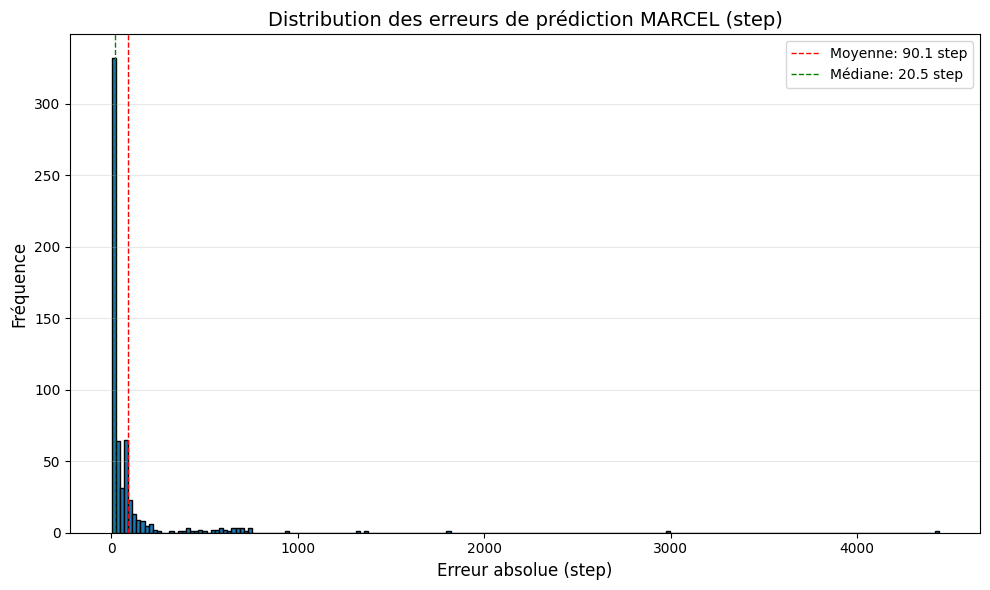

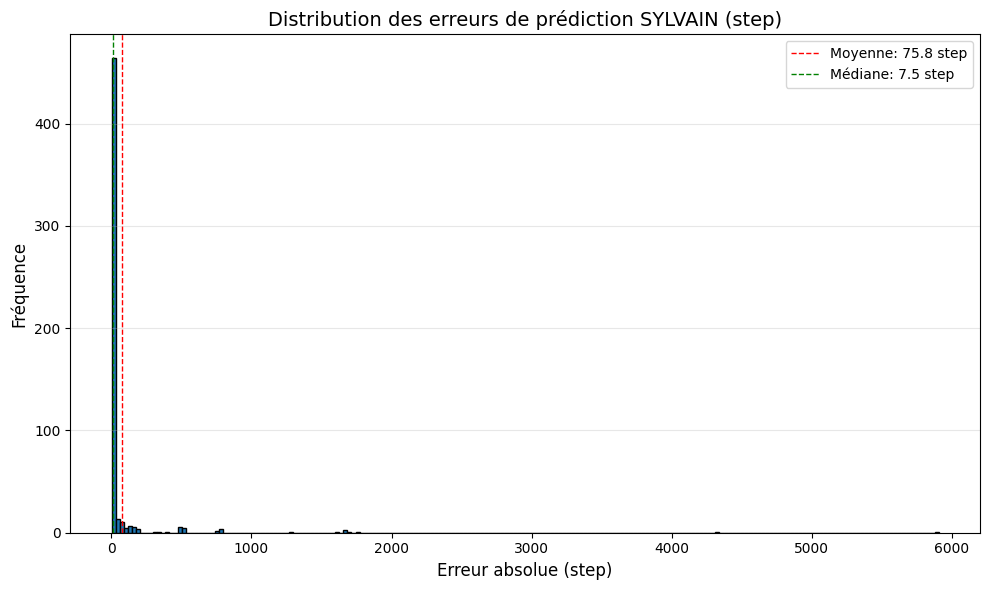

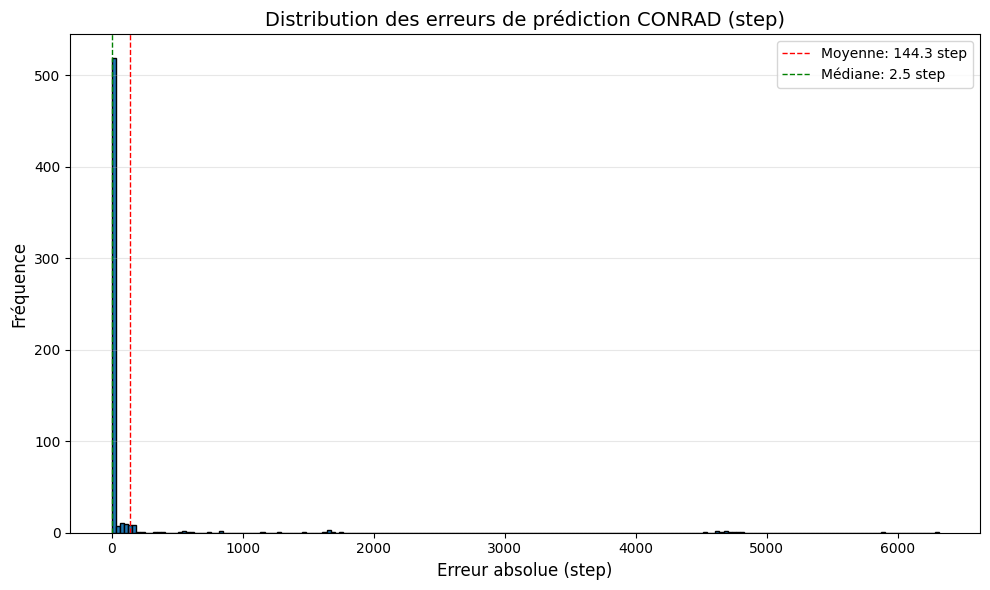

In [81]:
for horizon in HORIZONS:
    # Création de l'histogramme
    plt.figure(figsize=(10, 6))
    plt.hist(errors[horizon], bins=200, edgecolor='k')

    # Ajout des labels et titre
    plt.title(f"Distribution des erreurs de prédiction {horizon} (step)", fontsize=14)
    plt.xlabel("Erreur absolue (step)", fontsize=12)
    plt.ylabel("Fréquence", fontsize=12)

    # Affichage des statistiques
    plt.axvline(np.mean(errors[horizon]), color='red', linestyle='--', linewidth=1, label=f'Moyenne: {np.mean(errors[horizon]):.1f} step')
    plt.axvline(np.median(errors[horizon]), color='green', linestyle='--', linewidth=1, label=f'Médiane: {np.median(errors[horizon]):.1f} step')

    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    # Affichage
    plt.show()

Optimisation de l'hyperparamètre radius

--- Début de l'optimisation du rayon pour MARCEL ---
Rayon  0 | Erreur moyenne : 90.13 m | Erreur médiane : 20.50 m
Rayon  1 | Erreur moyenne : 90.07 m | Erreur médiane : 21.08 m
Rayon  2 | Erreur moyenne : 89.78 m | Erreur médiane : 20.70 m
Rayon  3 | Erreur moyenne : 89.62 m | Erreur médiane : 20.09 m
Rayon  4 | Erreur moyenne : 89.56 m | Erreur médiane : 19.48 m
Rayon  5 | Erreur moyenne : 89.59 m | Erreur médiane : 18.86 m
Rayon  6 | Erreur moyenne : 89.60 m | Erreur médiane : 18.77 m
Rayon  7 | Erreur moyenne : 89.52 m | Erreur médiane : 18.65 m
Rayon  8 | Erreur moyenne : 89.30 m | Erreur médiane : 18.64 m
Rayon  9 | Erreur moyenne : 89.06 m | Erreur médiane : 19.11 m
Rayon 10 | Erreur moyenne : 88.80 m | Erreur médiane : 19.01 m
Rayon 11 | Erreur moyenne : 88.54 m | Erreur médiane : 19.05 m
Rayon 12 | Erreur moyenne : 88.12 m | Erreur médiane : 19.32 m
Rayon 13 | Erreur moyenne : 87.69 m | Erreur médiane : 19.43 m
Rayon 14 | Erreur moyenne : 87.17 m | Erreur médiane : 19.34 m
Ra

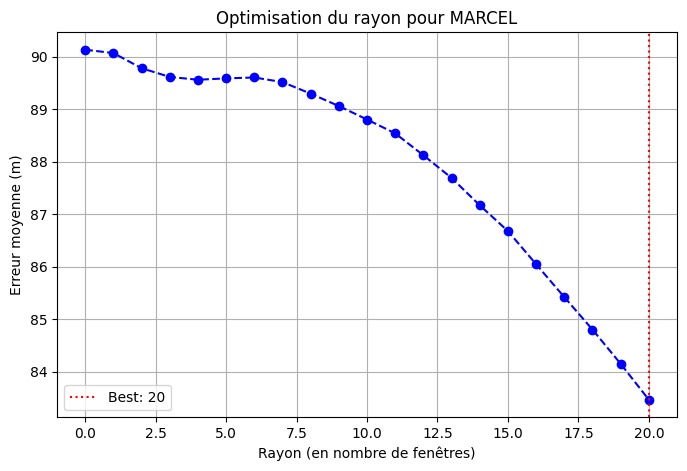

--- Début de l'optimisation du rayon pour SYLVAIN ---
Rayon  0 | Erreur moyenne : 75.83 m | Erreur médiane : 7.50 m
Rayon  1 | Erreur moyenne : 75.78 m | Erreur médiane : 7.30 m
Rayon  2 | Erreur moyenne : 75.65 m | Erreur médiane : 6.94 m
Rayon  3 | Erreur moyenne : 75.40 m | Erreur médiane : 6.20 m
Rayon  4 | Erreur moyenne : 75.12 m | Erreur médiane : 5.61 m
Rayon  5 | Erreur moyenne : 74.92 m | Erreur médiane : 5.18 m
Rayon  6 | Erreur moyenne : 74.70 m | Erreur médiane : 4.48 m
Rayon  7 | Erreur moyenne : 74.59 m | Erreur médiane : 4.07 m
Rayon  8 | Erreur moyenne : 74.52 m | Erreur médiane : 3.87 m
Rayon  9 | Erreur moyenne : 74.56 m | Erreur médiane : 3.86 m
Rayon 10 | Erreur moyenne : 74.60 m | Erreur médiane : 4.23 m
Rayon 11 | Erreur moyenne : 74.71 m | Erreur médiane : 4.75 m
Rayon 12 | Erreur moyenne : 74.90 m | Erreur médiane : 5.52 m
Rayon 13 | Erreur moyenne : 75.16 m | Erreur médiane : 6.11 m
Rayon 14 | Erreur moyenne : 75.36 m | Erreur médiane : 6.75 m
Rayon 15 | Erreu

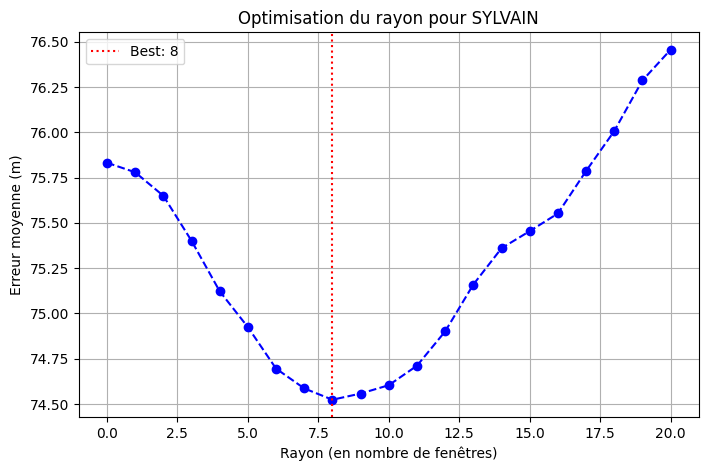

--- Début de l'optimisation du rayon pour CONRAD ---
Rayon  0 | Erreur moyenne : 144.34 m | Erreur médiane : 2.50 m
Rayon  1 | Erreur moyenne : 144.20 m | Erreur médiane : 2.40 m
Rayon  2 | Erreur moyenne : 143.91 m | Erreur médiane : 1.96 m
Rayon  3 | Erreur moyenne : 143.76 m | Erreur médiane : 1.71 m
Rayon  4 | Erreur moyenne : 143.78 m | Erreur médiane : 1.85 m
Rayon  5 | Erreur moyenne : 143.95 m | Erreur médiane : 2.14 m
Rayon  6 | Erreur moyenne : 144.12 m | Erreur médiane : 2.43 m
Rayon  7 | Erreur moyenne : 144.30 m | Erreur médiane : 2.74 m
Rayon  8 | Erreur moyenne : 144.38 m | Erreur médiane : 2.74 m
Rayon  9 | Erreur moyenne : 144.38 m | Erreur médiane : 2.85 m
Rayon 10 | Erreur moyenne : 144.39 m | Erreur médiane : 2.84 m
Rayon 11 | Erreur moyenne : 144.40 m | Erreur médiane : 2.88 m
Rayon 12 | Erreur moyenne : 144.59 m | Erreur médiane : 3.39 m
Rayon 13 | Erreur moyenne : 145.27 m | Erreur médiane : 4.11 m
Rayon 14 | Erreur moyenne : 146.01 m | Erreur médiane : 5.42 m
Ra

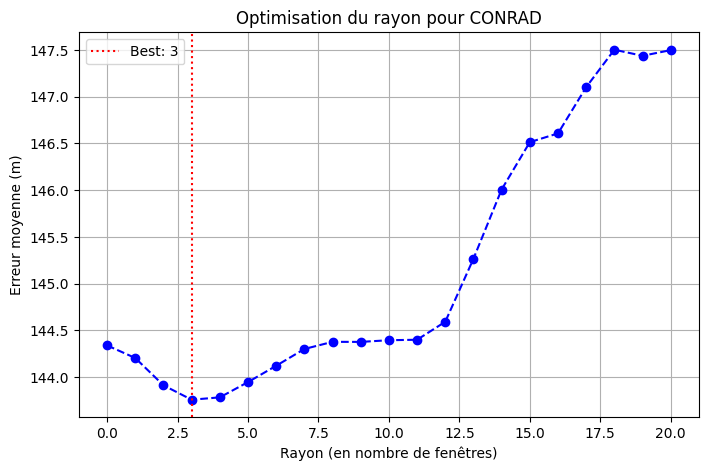

In [82]:
for horizon in HORIZONS:
    # Liste des rayons à tester (on commence petit et on élargit)
    radi_to_test = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
    mean_errors = []
    mdn_errors = []
    print(f"--- Début de l'optimisation du rayon pour {horizon} ---")

    for r in radi_to_test:
        current_errors = []
        
        for well in annotated_wells[horizon]:
            # On appelle ta fonction modifiée avec le rayon 'r'
            pred, _, _ = predict_top(encoder[horizon], well, df_logs, radius=r)
            
            # Récupération de la vérité terrain
            true_top = df_tops[df_tops['wellName'] == well].iloc[0][horizon]
            
            # Calcul de l'erreur
            err = abs(pred - true_top)
            current_errors.append(err)
        
        # Calcul de la moyenne pour ce rayon
        avg_err = np.mean(current_errors)
        mdn_err = np.median(current_errors)
        mdn_errors.append(mdn_err)
        mean_errors.append(avg_err)
        print(f"Rayon {r:2d} | Erreur moyenne : {avg_err:.2f} m | Erreur médiane : {mdn_err:.2f} m")

    # Trouver le meilleur rayon
    best_radius = radi_to_test[np.argmin(mean_errors)]
    print(f"\n>>> Le meilleur rayon pour {horizon} est : {best_radius} avec une erreur moyenne de {mean_errors[np.argmin(mean_errors)]:.2f} m et mediane de {mdn_errors[np.argmin(mean_errors)]:.2f} m")


    plt.figure(figsize=(8, 5))
    plt.plot(radi_to_test, mean_errors, marker='o', linestyle='--', color='b')
    plt.axvline(x=best_radius, color='r', linestyle=':', label=f'Best: {best_radius}')
    plt.title(f"Optimisation du rayon pour {horizon}")
    plt.xlabel("Rayon (en nombre de fenêtres)")
    plt.ylabel("Erreur moyenne (m)")
    plt.grid(True)
    plt.legend()
    plt.show()

| Horizon | Erreur Moyenne | Erreur Médiane | Rayon optimal | Erreur Moyenne avec optimisation | Erreur Médiane avec optimisation |
|----------|----------:|----------:|----------:|----------:|----------:|
| MARCEL  | 90.1 | 20.5 | 20 | 83.47 | 16.27 |
| CONRAD  | 75.8 | 7.5 | 8 | 74.52 | 3.87 |
| SYLVAIN | 144.3 | 2.5 | 3 | 143.76 | 1.71 |